# M0 — Monthly Panel EDA & Data Card

**Goal:** validate the output of `src/features/build_panel.py` before any model is trained on it.

**Outputs reviewed:**
- `data/processed/monthly_panel.parquet` — one row per (product, month)
- `data/processed/panel_meta.parquet` — product-level meta + cohort

**Sections**
1. Load & shape
2. Cross-checks vs. raw SQL
3. The 2017-09 truncation (visual)
4. Product cohorts (A_active vs B_sparse)
5. Quantity / price / discount distributions
6. Risk-rate panels (fraud / cancel / late)
7. Train / val / test split visualization
8. Final data card summary

In [1]:
import sys, sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PANEL = pd.read_parquet(ROOT / 'data' / 'processed' / 'monthly_panel.parquet')
META  = pd.read_parquet(ROOT / 'data' / 'processed' / 'panel_meta.parquet')

sns.set_theme(context='notebook', style='whitegrid')
print('panel:', PANEL.shape, ' meta:', META.shape)
PANEL.head()

panel: (4366, 32)  meta: (118, 9)


,product_card_id,year_month,gross_qty,n_orders_total,fraud_rate,cancel_rate,late_rate,shipping_delay_mean,p_list,qty,...,category_name,department_id,department_name,year,month,quarter,is_q4,is_nov_dec,split,data_quality
0,19.0,2015-01-01,0.0,0.0,NaN,NaN,NaN,NaN,124.989998,0.0,...,Soccer,2.0,Fitness,2015,1,1,0,0,train,ok
1,19.0,2015-02-01,0.0,0.0,NaN,NaN,NaN,NaN,124.989998,0.0,...,Soccer,2.0,Fitness,2015,2,1,0,0,train,ok
2,19.0,2015-03-01,0.0,0.0,NaN,NaN,NaN,NaN,124.989998,0.0,...,Soccer,2.0,Fitness,2015,3,1,0,0,train,ok
3,19.0,2015-04-01,0.0,0.0,NaN,NaN,NaN,NaN,124.989998,0.0,...,Soccer,2.0,Fitness,2015,4,2,0,0,train,ok
4,19.0,2015-05-01,0.0,0.0,NaN,NaN,NaN,NaN,124.989998,0.0,...,Soccer,2.0,Fitness,2015,5,2,0,0,train,ok


## 1. Shape & schema

In [2]:
print('rows:', len(PANEL))
print('unique products:', PANEL['product_card_id'].nunique())
print('unique months  :', PANEL['year_month'].nunique())
print('expected rows  :', PANEL['product_card_id'].nunique() * PANEL['year_month'].nunique())
PANEL.dtypes

rows: 4366
unique products: 118
unique months  : 37
expected rows  : 4366


product_card_id               float64
year_month             datetime64[us]
gross_qty                     float64
n_orders_total                float64
fraud_rate                    float64
cancel_rate                   float64
late_rate                     float64
shipping_delay_mean           float64
p_list                        float64
qty                           float64
revenue_realized              float64
p_eff                         float64
discount_rate_avg             float64
discount_rate_std             float64
n_orders_realized             float64
mkt_africa                    float64
mkt_europe                    float64
mkt_latam                     float64
mkt_pacific_asia              float64
mkt_usca                      float64
product_name                      str
category_id                   float64
category_name                     str
department_id                 float64
department_name                   str
year                            int16
month       

## 2. Cross-checks vs raw SQL

If these don't match, the panel is wrong.

In [3]:
with sqlite3.connect(ROOT / 'data' / 'dataco.db') as c:
    sql_rev  = c.execute("SELECT SUM(sales) FROM supply_chain WHERE order_status NOT IN ('CANCELED','SUSPECTED_FRAUD')").fetchone()[0]
    sql_qty  = c.execute('SELECT SUM(order_item_quantity) FROM supply_chain').fetchone()[0]
    sql_prod = c.execute('SELECT COUNT(DISTINCT product_card_id) FROM supply_chain').fetchone()[0]

checks = pd.DataFrame([
    ['revenue (realized)', PANEL['revenue_realized'].sum(), sql_rev],
    ['gross quantity',     PANEL['gross_qty'].sum(),         sql_qty],
    ['unique products',    PANEL['product_card_id'].nunique(), sql_prod],
], columns=['metric','panel','sql'])
checks['delta'] = checks['panel'] - checks['sql']
checks

,metric,panel,sql,delta
0,revenue (realized),3.521443e+07,3.521443e+07,0.0
1,gross quantity,3.840790e+05,3.840790e+05,0.0
2,unique products,1.180000e+02,1.180000e+02,0.0


## 3. The 2017-09 truncation

The DataCo dataset is severely truncated after **2017-09** (Oct 2017 → Jan 2018 only contain a small subset of products). We **keep these rows in the panel for documentation** but flag them via `data_quality == 'truncated'` and exclude them from train/val/test.

See `memory/project_data_quality_truncation.md` for the full decision record.

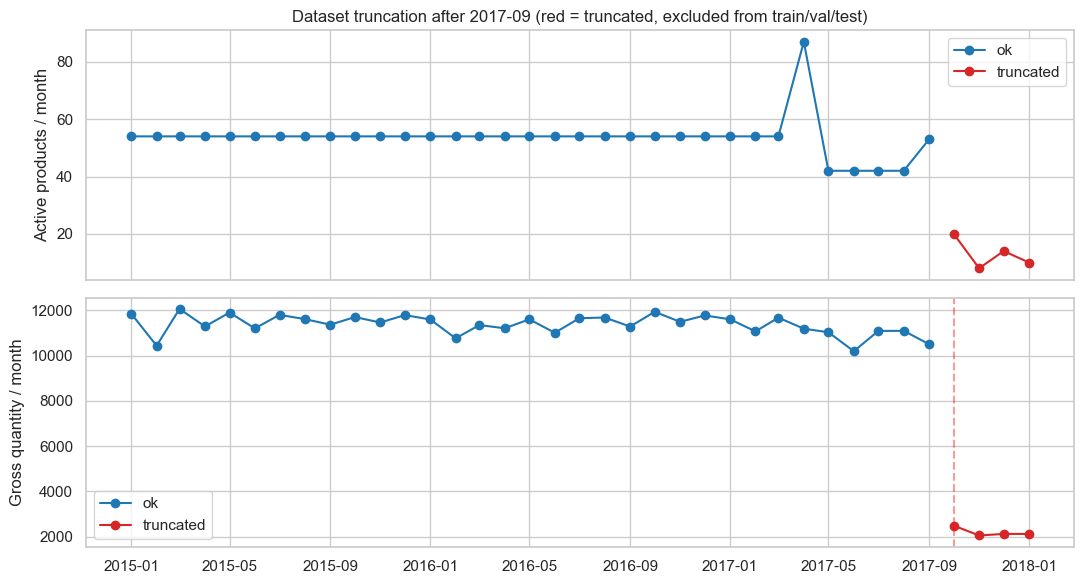

In [4]:
monthly = (PANEL.groupby('year_month')
                .agg(rows=('product_card_id','size'),
                     active_products=('qty', lambda s: (s>0).sum()),
                     gross_qty=('gross_qty','sum'),
                     revenue=('revenue_realized','sum'),
                     data_quality=('data_quality','first'))
                .reset_index())

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for col, axx, label in [('active_products', ax[0], 'Active products / month'),
                        ('gross_qty', ax[1], 'Gross quantity / month')]:
    palette = {'ok':'#1f77b4', 'truncated':'#d62728'}
    for q, sub in monthly.groupby('data_quality'):
        axx.plot(sub['year_month'], sub[col], 'o-', color=palette[q], label=q)
    axx.set_ylabel(label); axx.legend()
ax[1].axvline(pd.Timestamp('2017-10-01'), color='red', ls='--', alpha=0.4)
ax[0].set_title('Dataset truncation after 2017-09 (red = truncated, excluded from train/val/test)')
plt.tight_layout(); plt.show()

## 4. Product cohorts

In [5]:
print(META['cohort'].value_counts())
print()
print('top-10 by revenue:')
META.sort_values('total_revenue', ascending=False).head(10)[['product_card_id','product_name','category_name','total_revenue','months_active','cohort']]

cohort
B_sparse    64
A_active    54
Name: count, dtype: int64

top-10 by revenue:


,product_card_id,product_name,category_name,total_revenue,months_active,cohort
96,1004.0,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,6.637668e+06,34,A_active
35,365.0,Perfect Fitness Perfect Rip Deck,Cleats,4.233794e+06,34,A_active
92,957.0,Diamondback Women's Serene Classic Comfort Bi,Camping & Hiking,3.946837e+06,34,A_active
15,191.0,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment,3.507549e+06,34,A_active
37,502.0,Nike Men's Dri-FIT Victory Golf Polo,Women's Apparel,3.011600e+06,34,A_active
99,1073.0,Pelican Sunstream 100 Kayak,Water Sports,2.967852e+06,34,A_active
97,1014.0,O'Brien Men's Neoprene Life Vest,Indoor/Outdoor Games,2.765543e+06,34,A_active
36,403.0,Nike Men's CJ Elite 2 TD Football Cleat,Men's Footwear,2.763977e+06,34,A_active
44,627.0,Under Armour Girls' Toddler Spine Surge Runni,Shop By Sport,1.214896e+06,34,A_active
105,1351.0,Dell Laptop,Computers,6.375000e+05,2,B_sparse


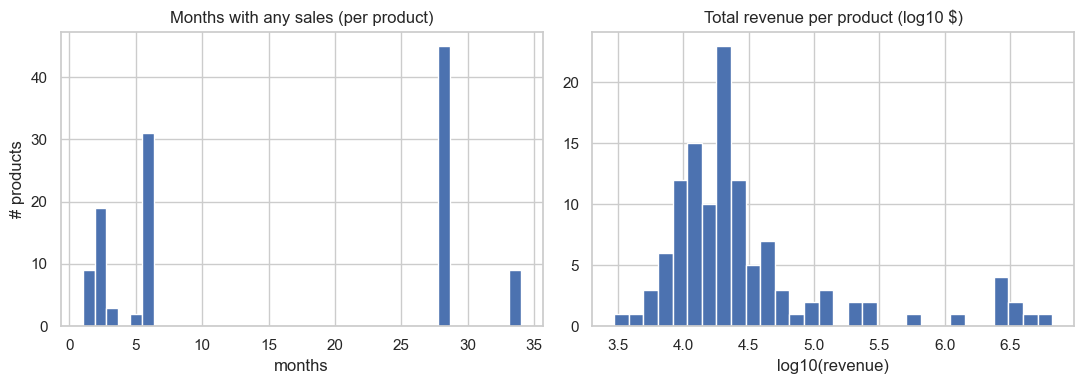

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
META['months_active'].hist(bins=37, ax=ax[0])
ax[0].set(title='Months with any sales (per product)', xlabel='months', ylabel='# products')
ax[1].hist(np.log10(META['total_revenue'].replace(0, np.nan).dropna()), bins=30)
ax[1].set(title='Total revenue per product (log10 $)', xlabel='log10(revenue)')
plt.tight_layout(); plt.show()

## 5. Quantity / price / discount

Only the **clean window** (`data_quality == 'ok'`) and **cohort A** (active products).

clean cohort-A rows: 1782


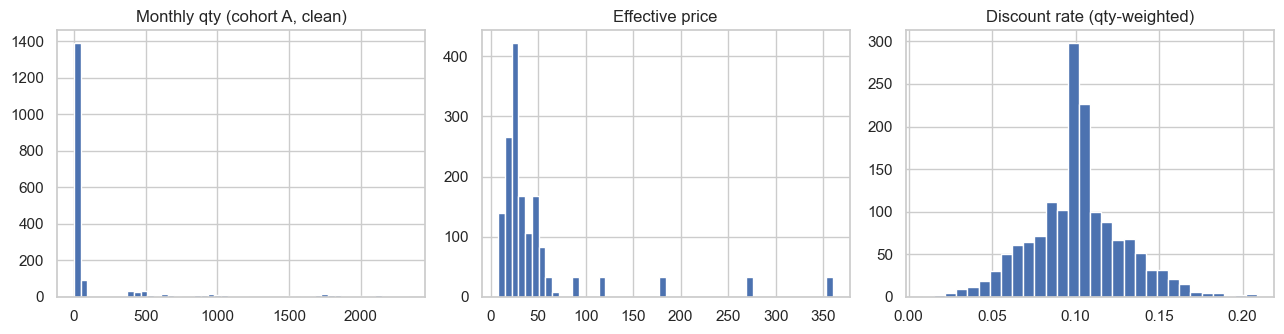

In [7]:
ids_A = META.loc[META['cohort']=='A_active', 'product_card_id']
clean = PANEL[(PANEL['product_card_id'].isin(ids_A)) & (PANEL['data_quality']=='ok')].copy()
print('clean cohort-A rows:', len(clean))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(clean['qty'], bins=50);            axes[0].set(title='Monthly qty (cohort A, clean)')
axes[1].hist(clean['p_eff'].dropna(), bins=50); axes[1].set(title='Effective price')
axes[2].hist(clean['discount_rate_avg'].dropna(), bins=30); axes[2].set(title='Discount rate (qty-weighted)')
plt.tight_layout(); plt.show()

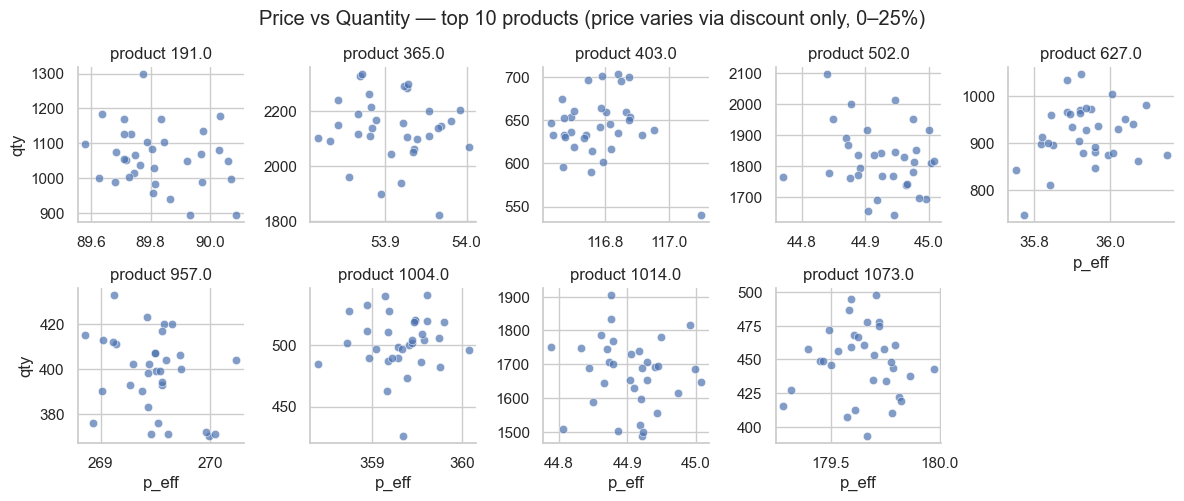

In [8]:
# Price-quantity relationship — preview of the elasticity signal we have to work with.
top10 = META.sort_values('total_revenue', ascending=False).head(10)['product_card_id'].tolist()
g = sns.relplot(data=clean[clean['product_card_id'].isin(top10)],
                x='p_eff', y='qty', col='product_card_id', col_wrap=5,
                kind='scatter', height=2.4, alpha=0.7, facet_kws={'sharex':False,'sharey':False})
g.set_titles('product {col_name}')
g.fig.suptitle('Price vs Quantity — top 10 products (price varies via discount only, 0–25%)', y=1.04)
plt.show()

## 6. Risk rates over time

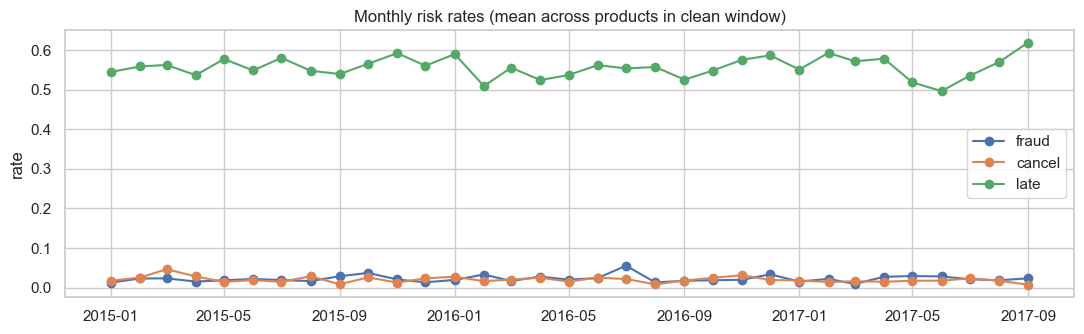

In [9]:
risk = (PANEL[PANEL['data_quality']=='ok']
            .groupby('year_month')
            .agg(fraud_rate=('fraud_rate','mean'),
                 cancel_rate=('cancel_rate','mean'),
                 late_rate=('late_rate','mean')).reset_index())
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(risk['year_month'], risk['fraud_rate'],  'o-', label='fraud')
ax.plot(risk['year_month'], risk['cancel_rate'], 'o-', label='cancel')
ax.plot(risk['year_month'], risk['late_rate'],   'o-', label='late')
ax.set(title='Monthly risk rates (mean across products in clean window)', ylabel='rate')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Train / val / test split

In [10]:
split_summary = (PANEL.groupby('split')
                      .agg(rows=('product_card_id','size'),
                           months=('year_month','nunique'),
                           min_month=('year_month','min'),
                           max_month=('year_month','max')).reset_index())
split_summary

,split,rows,months,min_month,max_month
0,test,354,3,2017-07-01,2017-09-01
1,train,2832,24,2015-01-01,2016-12-01
2,truncated,472,4,2017-10-01,2018-01-01
3,val,708,6,2017-01-01,2017-06-01


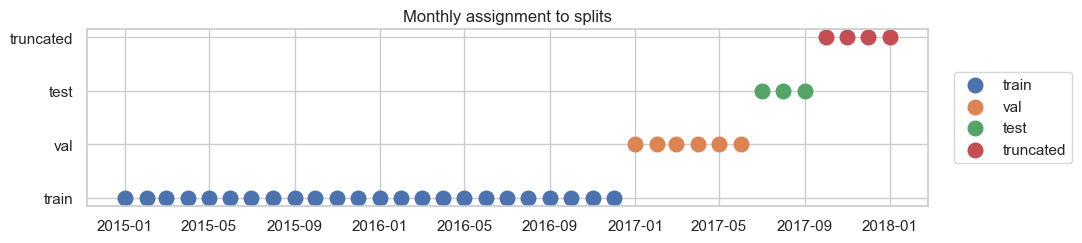

In [11]:
fig, ax = plt.subplots(figsize=(11, 2.6))
colors = {'train':'#4c72b0','val':'#dd8452','test':'#55a467','truncated':'#c44e52'}
for s, sub in PANEL.drop_duplicates('year_month').sort_values('year_month').groupby('split', sort=False):
    ax.scatter(sub['year_month'], [s]*len(sub), c=colors[s], s=110, label=s)
ax.set(title='Monthly assignment to splits', yticks=['train','val','test','truncated'])
ax.legend(loc='center right', bbox_to_anchor=(1.18, 0.5))
plt.tight_layout(); plt.show()

## 8. Data card — summary

| Item | Value |
|---|---|
| Source | `data/dataco.db::supply_chain` (180,519 order rows) |
| Panel grain | `(product_card_id, year_month)`, monthly |
| Panel shape | 4,366 rows × 32 cols (118 products × 37 months) |
| Clean window | 2015-01 → 2017-09 (33 months, 3,894 rows) |
| Truncated window | 2017-10 → 2018-01 (4 months, 472 rows, **flagged, excluded**) |
| Splits | train 24mo / val 6mo / test 3mo |
| Cohorts | A_active = 54 products (≥12 months active), B_sparse = 64 |
| Price signal | discount-driven only (0–25% range) — elasticity identified only in this range |
| Risk fields | fraud_rate, cancel_rate, late_rate (in-data); disaster proxy to be added in M3d |

**Known limitations**
1. Discount range is narrow (0–25%) — elasticity estimates do not extrapolate beyond.
2. Late-delivery field is a binary risk flag, not a measured outcome.
3. Cohort B (sparse) products will rely on category roll-up forecasts.
4. No native disaster data — M3d will use a synthetic proxy (per project plan).

**Next phase:** M1 — Demand forecasting (TimesFM + classical baselines).